In [ ]:
import numpy as np
import pandas as pd

if __name__ == '__main__':
    from google.colab import drive
    drive.mount('/content/drive')
    training_data = pd.read_csv('/content/drive/MyDrive/COMP4211/pa1/dataset/train.csv', delimiter=',')
    testing_data = pd.read_csv('/content/drive/MyDrive/COMP4211/pa1/dataset/test.csv', delimiter=',')


Mounted at /content/drive


FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/COMP4211/pa1/dataset/train.csv'

**Part 1: Data Exploration and Preparation**

Load the provided train.csv file using pandas. Write code to perform an initial data exploration
to understand the basic statistics about all the attributes and target variables. Although you
need to run the code to explore this dataset, you need to answer the questions [Q1] to [Q6] on
the training set. Your report should include:

[Q1] Dataset Overview.

• Size of the Dataset: Total number of instances and features.

• Feature Types: Identify numerical and categorical features.

In [ ]:
# @title
training_data.info()
print("Training data: \nInstance: {} , Feature: {}".format(training_data.shape[0], training_data.shape[1]))
print("Testing data: \nInstance: {} , Feature: {}".format(testing_data.shape[0], testing_data.shape[1]))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 196817 entries, 0 to 196816
Data columns (total 36 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   RaceEthnicityCategory      196817 non-null  object 
 1   PneumoVaxEver              196817 non-null  object 
 2   LastCheckupTime            196817 non-null  object 
 3   SmokerStatus               196817 non-null  object 
 4   HadAngina                  196817 non-null  object 
 5   HadDepressiveDisorder      196817 non-null  object 
 6   DifficultyConcentrating    196817 non-null  object 
 7   RemovedTeeth               196817 non-null  object 
 8   BlindOrVisionDifficulty    196817 non-null  object 
 9   GeneralHealth              196817 non-null  object 
 10  HadSkinCancer              196817 non-null  object 
 11  HighRiskLastYear           196817 non-null  object 
 12  ECigaretteUsage            196817 non-null  object 
 13  ChestScan                  19

[Q2] Missing Values.

• Identification: Report any features with missing values and the proportion of missing
values for them.

• Potential Impact: Briefly discuss how these missing values might affect analysis and
model performance.


In [ ]:
print("features with missing values:")
print(training_data.isnull().sum())

print("---------------------------------------------------------------------------")
print("proportion of missing values:")
print(training_data.isnull().sum() /len(training_data))

features with missing values:
RaceEthnicityCategory           0
PneumoVaxEver                   0
LastCheckupTime                 0
SmokerStatus                    0
HadAngina                       0
HadDepressiveDisorder           0
DifficultyConcentrating         0
RemovedTeeth                    0
BlindOrVisionDifficulty         0
GeneralHealth                   0
HadSkinCancer                   0
HighRiskLastYear                0
ECigaretteUsage                 0
ChestScan                       0
HadStroke                       0
FluVaxLast12                    0
Sex                             0
HadDiabetes                     0
BMI                          8258
PhysicalHealthDays              0
HadKidneyDisease                0
AlcoholDrinkers                 0
SleepHours                      0
DeafOrHardOfHearing             0
CovidPos                        0
HadAsthma                       0
DifficultyWalking               0
HadCOPD                         0
MentalHealthDays  

[Q3] Feature Distribution.

• Numerical Features: Identify which ones are discrete or continuous. Describe the dis-
tribution (i.e., mean, median, range, standard deviation) of all numerical features, and
visualize the distribution of one of the numerical features using a box plot.

• Categorical Features: Identify which ones are binary, nominal, or ordinal. Select 2 of
the categorical features, summarize the count of categories for each, and visualize their
distributions using bar plots.

In [ ]:
numerical_training_data = training_data.select_dtypes(include=['int64', 'float64'])
numerical_training_data.describe()

,BMI,PhysicalHealthDays,SleepHours,MentalHealthDays,Age,HadHeartAttack
count,188559.000000,196817.000000,196817.000000,196817.000000,196817.000000,196817.000000
mean,28.677420,4.118486,7.020466,4.177403,55.750171,0.054604
std,6.514538,8.405127,1.441551,8.112694,17.551129,0.227206
min,12.020000,0.000000,1.000000,0.000000,18.600000,0.000000
25%,24.280000,0.000000,6.000000,0.000000,42.300000,0.000000
50%,27.460000,0.000000,7.000000,0.000000,57.500000,0.000000
75%,31.890000,3.000000,8.000000,4.000000,70.900000,0.000000
max,97.650000,30.000000,24.000000,30.000000,84.000000,1.000000


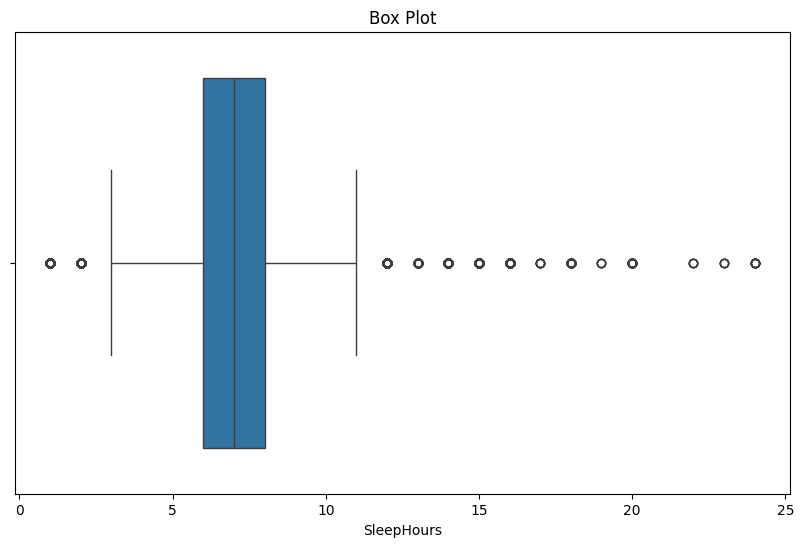

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

chosen_feature = "SleepHours"
plt.figure(figsize=(10, 6))
sns.boxplot(x=chosen_feature, data=training_data)
plt.title('Box Plot')
plt.show()

In [ ]:
chosen_feature = "GeneralHealth"
training_data[chosen_feature].value_counts()

,count
GeneralHealth,
Very good,69537
Good,61921
Excellent,33329
Fair,24499
Poor,7531


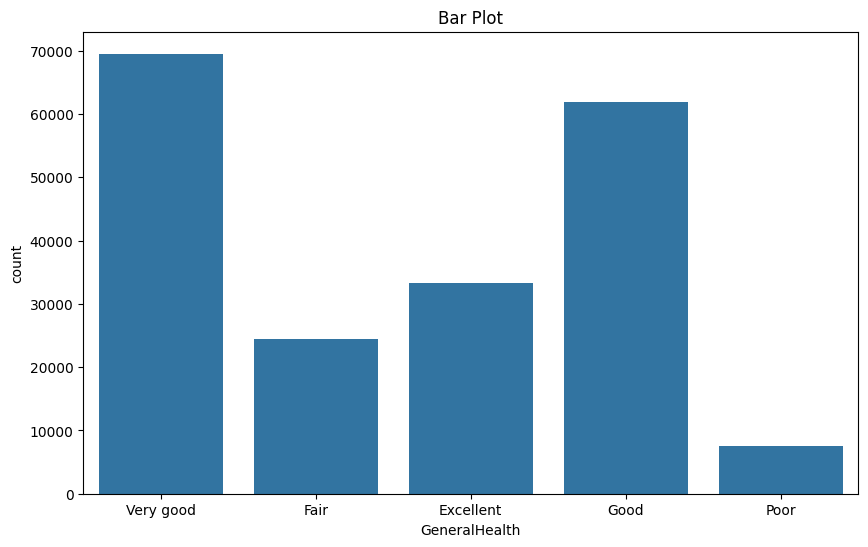

In [ ]:
plt.figure(figsize=(10, 6))
sns.countplot(x=chosen_feature, data=training_data)
plt.title('Bar Plot')
plt.show()

In [ ]:
chosen_feature = "PhysicalActivities"
training_data[chosen_feature].value_counts()

,count
PhysicalActivities,
Yes,152911
No,43906


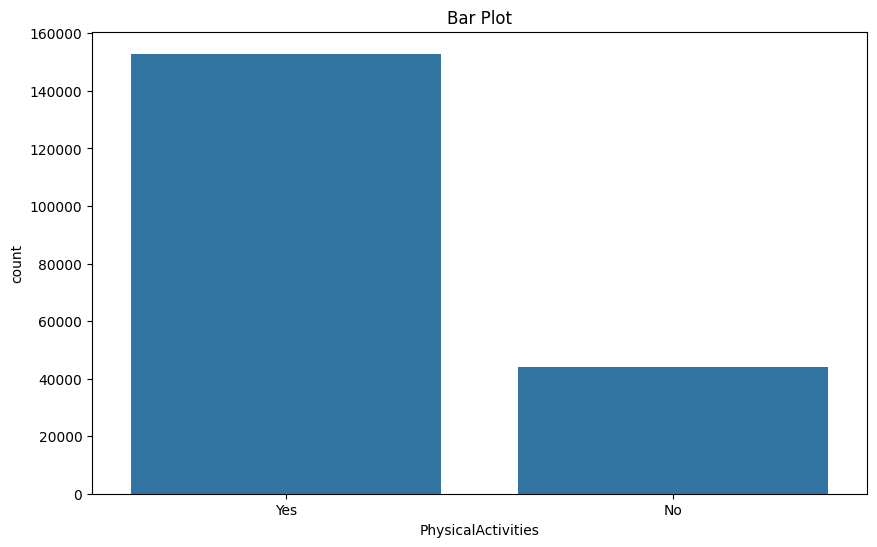

In [ ]:
plt.figure(figsize=(10, 6))
sns.countplot(x=chosen_feature, data=training_data)
plt.title('Bar Plot')
plt.show()

[Q4] Correlation Analysis.

• Feature Correlation: Visualize the correlation between every two features (numerical
features only, including the regression targets) with a heatmap. You can use matplotlib
and seaborn to help you.

• Insights: Highlight any strong correlations that might influence feature selection or ne-
cessitate feature engineering.

In [ ]:
numerical_training_data.corr()

,BMI,PhysicalHealthDays,SleepHours,MentalHealthDays,Age,HadHeartAttack
BMI,1.000000,0.118360,-0.053317,0.083385,-0.023303,0.031346
PhysicalHealthDays,0.118360,1.000000,-0.056793,0.305924,0.090654,0.134355
SleepHours,-0.053317,-0.056793,1.000000,-0.131412,0.123893,0.003212
MentalHealthDays,0.083385,0.305924,-0.131412,1.000000,-0.190143,0.024669
Age,-0.023303,0.090654,0.123893,-0.190143,1.000000,0.171351
HadHeartAttack,0.031346,0.134355,0.003212,0.024669,0.171351,1.000000


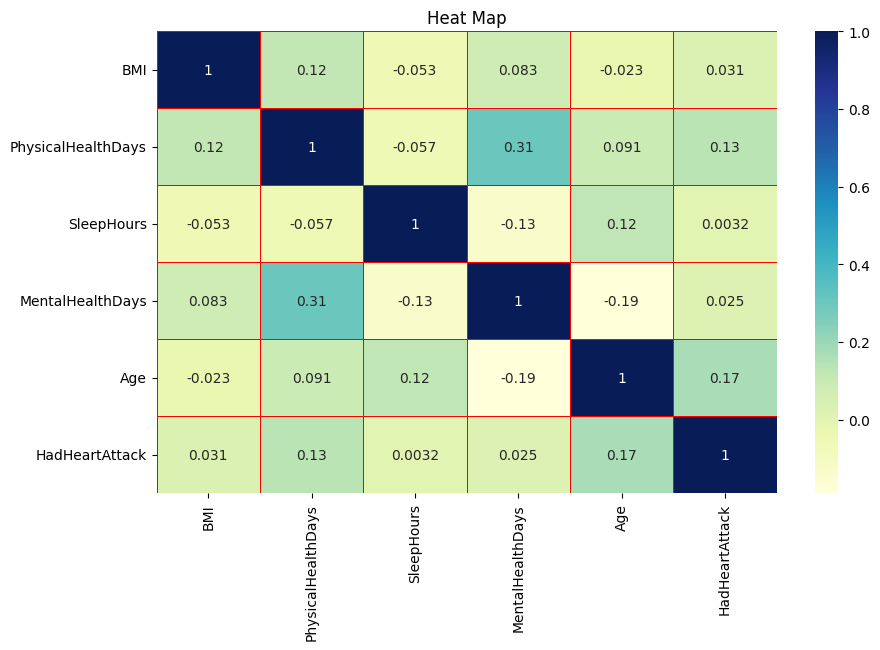

In [ ]:
plt.figure(figsize=(10, 6))
sns.heatmap(numerical_training_data.corr(), annot=True, cmap='YlGnBu', linecolor='r', linewidths=0.5)
plt.title('Heat Map')
plt.show()

[Q5] Handling Missing Values

Apply SimpleImputer to handle missing values.

Briefly dis-cuss its impact on feature distribution and model performance.

Briefly discuss what imputation strategies (mean, median, mode, and constant) should be used for what reasons.

In [ ]:
from sklearn.impute import SimpleImputer

impute = SimpleImputer(strategy='median')
numerical_training_data_imputed = pd.DataFrame(impute.fit_transform(numerical_training_data), columns=numerical_training_data.columns)
numerical_training_data_imputed

,BMI,PhysicalHealthDays,SleepHours,MentalHealthDays,Age,HadHeartAttack
0,25.10,0.0,8.0,15.0,41.9,0.0
1,22.60,0.0,10.0,0.0,42.3,0.0
2,33.45,1.0,6.0,0.0,66.3,0.0
3,23.11,0.0,8.0,0.0,32.3,0.0
4,32.89,15.0,4.0,15.0,71.4,1.0
...,...,...,...,...,...,...
196812,40.45,0.0,8.0,0.0,72.8,0.0
196813,27.46,0.0,8.0,0.0,47.2,0.0
196814,36.96,0.0,7.0,0.0,67.3,0.0
196815,23.91,0.0,8.0,1.0,72.5,0.0


[Q6] Normalization and Standardization:

Normalize/standardize different types of numerical features using StandardScaler, MinMaxScaler, or RobustScaler.

You need to report the first numerical feature column of the first 10 samples before and after processing.

Briefly discuss the difference between these techniques and when to use each.


In [ ]:
numerical_training_data_imputed.iloc[:10, 0]
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler

standard_scaler = StandardScaler()
minmax_scaler = MinMaxScaler()
robust_scaler = RobustScaler()

numerical_training_data_standard = pd.DataFrame(standard_scaler.fit_transform(numerical_training_data_imputed), columns=numerical_training_data_imputed.columns)
numerical_training_data_minmax = pd.DataFrame(minmax_scaler.fit_transform(numerical_training_data_imputed), columns=numerical_training_data_imputed.columns)
numerical_training_data_robust = pd.DataFrame(robust_scaler.fit_transform(numerical_training_data_imputed), columns=numerical_training_data_imputed.columns)

print("Before Processing:")
numerical_training_data_imputed.iloc[:10, 0]

Before Processing:


,BMI
0,25.10
1,22.60
2,33.45
3,23.11
4,32.89
5,20.18
6,32.49
7,24.33
8,35.44
9,21.77


In [ ]:
print("Standard:")
numerical_training_data_standard.iloc[:10, 0]

Standard:


,BMI
0,-0.552626
1,-0.944411
2,0.755934
3,-0.864487
4,0.668174
5,-1.323658
6,0.605489
7,-0.673296
8,1.067795
9,-1.074483


In [ ]:
print("Minmax:")
numerical_training_data_minmax.iloc[:10, 0]

Minmax:


,BMI
0,0.152750
1,0.123555
2,0.250263
3,0.129511
4,0.243723
5,0.095294
6,0.239052
7,0.143758
8,0.273502
9,0.113862


In [ ]:
print("Robust:")
numerical_training_data_robust.iloc[:10, 0]

Robust:


,BMI
0,-0.326418
1,-0.672199
2,0.828492
3,-0.601660
4,0.751037
5,-1.006916
6,0.695712
7,-0.432918
8,1.103734
9,-0.786999


[Q7] Encoding Categorical Variables:

Utilize OneHotEncoder and OrdinalEncoder to encode different types of categorical variables.

For certain ordinal feature(s), a direct application of
the OrdinalEncoder may lead to a suboptimal ranking between categories.

You need to handle this by adjusting the settings within the OrdinalEncoder.

Additionally, you need to report the entire table in the jupyter notebook, showing the first 10 samples before and after processing in pandas.DataFrame structure.

Briefly explain the scenarios where each encoding technique is
preferred.


In [ ]:
categorical_training_data = training_data.select_dtypes(include=['object', 'category']).columns.tolist()
print("Before Processing:")
training_data_extracted = training_data.select_dtypes(include=['object', 'category'])[:10]
training_data_extracted

Before Processing:


,RaceEthnicityCategory,PneumoVaxEver,LastCheckupTime,SmokerStatus,HadAngina,HadDepressiveDisorder,DifficultyConcentrating,RemovedTeeth,BlindOrVisionDifficulty,GeneralHealth,...,DeafOrHardOfHearing,CovidPos,HadAsthma,DifficultyWalking,HadCOPD,HadArthritis,DifficultyDressingBathing,HIVTesting,PhysicalActivities,DifficultyErrands
0,"White only, Non-Hispanic",No,1 year but less than 2 years ago (Within past ...,Never smoked,No,Yes,No,0,No,Very good,...,No,No,No,No,No,No,No,No,Yes,No
1,"White only, Non-Hispanic",No,Within past year (anytime less than 12 months ...,Current smoker - now smokes every day,No,Yes,No,"6 or more, but not all",No,Fair,...,No,Yes,Yes,No,No,No,No,Yes,Yes,Yes
2,"White only, Non-Hispanic",Yes,Within past year (anytime less than 12 months ...,Former smoker,No,No,No,0,No,Fair,...,No,No,No,Yes,No,Yes,No,No,No,Yes
3,"White only, Non-Hispanic",No,Within past year (anytime less than 12 months ...,Never smoked,No,No,No,0,No,Excellent,...,No,No,No,No,No,No,No,Yes,Yes,No
4,"White only, Non-Hispanic",No,Within past year (anytime less than 12 months ...,Former smoker,Yes,No,Yes,All,Yes,Fair,...,No,No,Yes,Yes,No,Yes,No,No,No,No
5,"Black only, Non-Hispanic",No,Within past year (anytime less than 12 months ...,Current smoker - now smokes every day,Yes,No,No,1 to 5,No,Very good,...,No,No,No,No,No,No,No,Yes,Yes,No
6,Hispanic,No,Within past year (anytime less than 12 months ...,Former smoker,No,No,No,0,No,Excellent,...,No,Yes,Yes,No,No,No,No,Yes,Yes,No
7,"Multiracial, Non-Hispanic",No,5 or more years ago,Current smoker - now smokes every day,No,No,No,All,Yes,Good,...,No,No,No,No,No,No,No,No,Yes,No
8,"White only, Non-Hispanic",No,Within past year (anytime less than 12 months ...,Current smoker - now smokes every day,No,Yes,No,1 to 5,No,Fair,...,No,Yes,No,Yes,No,Yes,No,Yes,Yes,No
9,"White only, Non-Hispanic",Yes,Within past year (anytime less than 12 months ...,Never smoked,No,Yes,No,0,No,Very good,...,No,No,No,No,No,No,No,Yes,Yes,No


In [ ]:
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder

print("After Processing:")
one_hot_encoder = OneHotEncoder(sparse_output=False, drop=None)
one_hot_encoded = one_hot_encoder.fit_transform(training_data[categorical_training_data])
one_hot_df = pd.DataFrame(one_hot_encoded, columns=one_hot_encoder.get_feature_names_out(categorical_training_data))

ordinal_encoder = OrdinalEncoder()
ordinal_encoded = ordinal_encoder.fit_transform(training_data[categorical_training_data])
ordinal_df = pd.DataFrame(ordinal_encoded, columns=ordinal_encoder.get_feature_names_out(categorical_training_data))

ordinal_training_data = {
    'LastCheckupTime':['Within past year (anytime less than 12 months ago)',
                       '1 year but less than 2 years ago (Within past 2 years)',
                       '2 year but less than 5 years ago (Within past 5 years)',
                       '5 or more years ago'
                      ],
    'RemovedTeeth':['0', '1 to 5', '6 or more, but not all', 'All'],
    'GeneralHealth':['Poor', 'Fair', 'Good', 'Very good', 'Excellent'],
    'ECigaretteUsage':['Never used e-cigarettes in my entire life',
                       'Not at all (right now)',
                       'Use them a few days',
                       'Use them every day'
                       ],
    'others':['No', 'Yes']
}
optimal_ordinal_encoder = OrdinalEncoder(categories=[ordinal_training_data[i] for i in ordinal_training_data])
optimal_ordinal_encoded = ordinal_encoder.fit_transform(training_data[categorical_training_data])
optimal_ordinal_df = pd.DataFrame(ordinal_encoded, columns=ordinal_encoder.get_feature_names_out(categorical_training_data))

After Processing:


In [ ]:
print("OneHotEncoder:")
one_hot_df[:10]

OneHotEncoder:


,"RaceEthnicityCategory_Black only, Non-Hispanic",RaceEthnicityCategory_Hispanic,"RaceEthnicityCategory_Multiracial, Non-Hispanic","RaceEthnicityCategory_Other race only, Non-Hispanic","RaceEthnicityCategory_White only, Non-Hispanic",PneumoVaxEver_No,PneumoVaxEver_Yes,LastCheckupTime_1 year but less than 2 years ago (Within past 2 years),LastCheckupTime_2 year but less than 5 years ago (Within past 5 years),LastCheckupTime_5 or more years ago,...,HadArthritis_No,HadArthritis_Yes,DifficultyDressingBathing_No,DifficultyDressingBathing_Yes,HIVTesting_No,HIVTesting_Yes,PhysicalActivities_No,PhysicalActivities_Yes,DifficultyErrands_No,DifficultyErrands_Yes
0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,...,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0
1,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0
2,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,...,0.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0
3,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0
4,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,...,0.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
5,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0
6,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0
7,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,...,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0
8,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,...,0.0,1.0,1.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0
9,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,...,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0


In [ ]:
print("OrdinalEncoder:")
ordinal_df[:10]

OrdinalEncoder:


,RaceEthnicityCategory,PneumoVaxEver,LastCheckupTime,SmokerStatus,HadAngina,HadDepressiveDisorder,DifficultyConcentrating,RemovedTeeth,BlindOrVisionDifficulty,GeneralHealth,...,DeafOrHardOfHearing,CovidPos,HadAsthma,DifficultyWalking,HadCOPD,HadArthritis,DifficultyDressingBathing,HIVTesting,PhysicalActivities,DifficultyErrands
0,4.0,0.0,0.0,3.0,0.0,1.0,0.0,0.0,0.0,4.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,4.0,0.0,3.0,0.0,0.0,1.0,0.0,2.0,0.0,1.0,...,0.0,2.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0
2,4.0,1.0,3.0,2.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0
3,4.0,0.0,3.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
4,4.0,0.0,3.0,2.0,1.0,0.0,1.0,3.0,1.0,1.0,...,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0
5,0.0,0.0,3.0,0.0,1.0,0.0,0.0,1.0,0.0,4.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
6,1.0,0.0,3.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,2.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
7,2.0,0.0,2.0,0.0,0.0,0.0,0.0,3.0,1.0,2.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
8,4.0,0.0,3.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,...,0.0,2.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0
9,4.0,1.0,3.0,3.0,0.0,1.0,0.0,0.0,0.0,4.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0


In [ ]:
print("Optimal OrdinalEncoder:")
optimal_ordinal_df[:10]

Optimal OrdinalEncoder:


,RaceEthnicityCategory,PneumoVaxEver,LastCheckupTime,SmokerStatus,HadAngina,HadDepressiveDisorder,DifficultyConcentrating,RemovedTeeth,BlindOrVisionDifficulty,GeneralHealth,...,DeafOrHardOfHearing,CovidPos,HadAsthma,DifficultyWalking,HadCOPD,HadArthritis,DifficultyDressingBathing,HIVTesting,PhysicalActivities,DifficultyErrands
0,4.0,0.0,0.0,3.0,0.0,1.0,0.0,0.0,0.0,4.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,4.0,0.0,3.0,0.0,0.0,1.0,0.0,2.0,0.0,1.0,...,0.0,2.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0
2,4.0,1.0,3.0,2.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0
3,4.0,0.0,3.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
4,4.0,0.0,3.0,2.0,1.0,0.0,1.0,3.0,1.0,1.0,...,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0
5,0.0,0.0,3.0,0.0,1.0,0.0,0.0,1.0,0.0,4.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
6,1.0,0.0,3.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,2.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
7,2.0,0.0,2.0,0.0,0.0,0.0,0.0,3.0,1.0,2.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
8,4.0,0.0,3.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,...,0.0,2.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0
9,4.0,1.0,3.0,3.0,0.0,1.0,0.0,0.0,0.0,4.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0


[Q8] Feature Selection:

Perform feature selection with either feature selection modules in scikit-learn, such as SelectKBest, or based on the correlation analysis on all features (including numerical and categorical features) similar to [Q5].

Think about how feature selection impacts the performance of your models.

You need to report which features were removed for what reasons

In [ ]:
from sklearn.feature_selection import SelectKBest, f_classif

combined_df = pd.concat([optimal_ordinal_df, numerical_training_data_minmax.iloc[:, :-2]],axis=1)

selector = SelectKBest(score_func=f_classif, k=26)
training_data_selected = selector.fit_transform(combined_df,training_data.iloc[:, -2:-1])
selected_features = selector.get_support(indices=True)
score = pd.DataFrame({'Feature':combined_df.columns, 'Score': selector.scores_}).sort_values(by='Score', ascending=False)
score

/usr/local/lib/python3.10/dist-packages/sklearn/utils/validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


,Feature,Score
1,PneumoVaxEver,136.999799
25,HadArthritis,69.047212
7,RemovedTeeth,57.118701
27,HIVTesting,41.328554
15,FluVaxLast12,37.222033
12,ECigaretteUsage,37.105845
13,ChestScan,31.126586
10,HadSkinCancer,30.162218
20,DeafOrHardOfHearing,25.321435
23,DifficultyWalking,24.735452


In this task, you will build multiple linear regression models in the first step, where each model uses only one feature to determine its correlation with the regression target (the second last column ‘Age’). In this stage, you only need to focus on binary categorical and continuous numerical features.

In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
import time

first_step_result = pd.DataFrame(columns=['Feature', 'R2', 'MSE', 'Time'])

non_binary_catagorical = ['RaceEthnicityCategory', 'SmokerStatus', 'LastCheckupTime', 'RemovedTeeth', 'GeneralHealth', 'ECigaretteUsage']

binary_and_numerical_selected = combined_df.columns.tolist()
for i in non_binary_catagorical:
  binary_and_numerical_selected.remove(i)

selected = combined_df.columns[selected_features].tolist()
binary_and_numerical_selected = list(set(binary_and_numerical_selected) & set(selected))
print(binary_and_numerical_selected)

for i in binary_and_numerical_selected:
  X = combined_df[i]
  Y = numerical_training_data_minmax['Age']
  X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=4211)
  model = LinearRegression()
  X_train = np.array(X_train).reshape(-1, 1)
  X_test = np.array(X_test).reshape(-1, 1)
  starting_time = time.time()
  model.fit(X_train, y_train)
  y_pred = model.predict(X_test)
  ending_time = time.time()
  training_time = ending_time - starting_time
  r2 = r2_score(y_test, y_pred)
  mse = mean_squared_error(y_test, y_pred)
  temp_result = pd.DataFrame({'Feature': [i], 'R2': [r2], 'MSE': [mse], 'Time': [training_time]})
  first_step_result = pd.concat([first_step_result, temp_result], ignore_index=True)

#first_step_result

['MentalHealthDays', 'PneumoVaxEver', 'FluVaxLast12', 'SleepHours', 'HadArthritis', 'CovidPos', 'PhysicalActivities', 'HIVTesting', 'HadCOPD', 'DeafOrHardOfHearing', 'DifficultyWalking', 'HadSkinCancer', 'HadStroke', 'AlcoholDrinkers', 'HighRiskLastYear', 'ChestScan', 'HadDiabetes', 'HadAngina', 'HadDepressiveDisorder', 'HadKidneyDisease', 'BMI']


<ipython-input-23-095dc1c8d7f0>:34: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  first_step_result = pd.concat([first_step_result, temp_result], ignore_index=True)




Then, in the second step, you will build another linear regression model using the features that yield the best performance in your experiment to explore their relationship with the regression target.

You are required to use the train test split submodule in scikit-learn to split the data in train.csv, with 80% for training and 20% for validation. You should set random state = 4211 for reproducibility.



In [ ]:
best_feature = first_step_result.nlargest(15, 'R2')['Feature'].tolist()
second_step_result = pd.DataFrame(columns=['Feature', 'R2', 'MSE', 'Time'])


X = combined_df[best_feature]
Y = numerical_training_data_minmax['Age']
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=4211)
model = LinearRegression()
starting_time = time.time()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
ending_time = time.time()
training_time = ending_time - starting_time
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
temp_result = pd.DataFrame({'Feature': 'Best Feature', 'R2': [r2], 'MSE': [mse], 'Time': [training_time]})
second_step_result = pd.concat([second_step_result, temp_result], ignore_index=True)

#second_step_result

<ipython-input-24-ed2f92619399>:17: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  second_step_result = pd.concat([second_step_result, temp_result], ignore_index=True)


[Q9] After training multiple models described above using the training set, use them to make predictions on the validation set. Report the validation R2 score of each of the models to evaluate the relationship between different features and the regression target.



In [ ]:
all_model = pd.concat([first_step_result, second_step_result], ignore_index=True)
all_model[['Feature','R2']]

,Feature,R2
0,MentalHealthDays,0.037071
1,PneumoVaxEver,0.171436
2,FluVaxLast12,0.076455
3,SleepHours,0.014153
4,HadArthritis,0.135914
5,CovidPos,0.028528
6,PhysicalActivities,0.010043
7,HIVTesting,0.047703
8,HadCOPD,0.020365
9,DeafOrHardOfHearing,0.043294


[Q10] Report the mean squared error of each of the models in the validation set and compare them based on the two performance metrics, i.e., R2 score and Mean Squared Error (MSE).



In [ ]:
all_model = pd.concat([first_step_result, second_step_result], ignore_index=True)
all_model[['Feature','MSE']]

,Feature,MSE
0,MentalHealthDays,0.069043
1,PneumoVaxEver,0.059409
2,FluVaxLast12,0.066219
3,SleepHours,0.070686
4,HadArthritis,0.061956
5,CovidPos,0.069655
6,PhysicalActivities,0.070981
7,HIVTesting,0.068281
8,HadCOPD,0.070241
9,DeafOrHardOfHearing,0.068597


[Q11] Discuss the mathematical meaning of the weight (in brief) for a binary categorical in-dependent variable. How can a nominal categorical feature with more than 2 possible values be formulated as the independent variable of a linear model? Include the necessary component of the nominal categorical features alongside the previously selected features to enhance the model’s performance compared to [Q9-Q10]. Report the validation R2 score and MSE of this linear regression model.

In [ ]:
enhance_result = pd.DataFrame(columns=['Feature', 'R2', 'MSE', 'Time'])
X = combined_df
Y = numerical_training_data_minmax['Age']
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=4211)
model = LinearRegression()
starting_time = time.time()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
ending_time = time.time()
training_time = ending_time - starting_time
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
temp_result = pd.DataFrame({'Feature': 'enhanced', 'R2': [r2], 'MSE': [mse], 'Time': [training_time]})
enhance_result = pd.concat([enhance_result, temp_result], ignore_index=True)

enhance_result

<ipython-input-27-2edacce72b2c>:14: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  enhance_result = pd.concat([enhance_result, temp_result], ignore_index=True)


,Feature,R2,MSE,Time
0,enhanced,0.512287,0.034969,0.236092


In this part, you are asked to use the features selected in Section 6.1 to train feedforward neural networks.

You need to try different numbers of hidden units H ∈ {1, 8, 32, 128} to build different three-hidden-layer neural networks. The hyperparameter early stopping can be set to ‘True’ to avoid overfitting (default is ‘False’). The other hyperparameters may just take their default values. For each hidden layer in a specific neural network model, the number of hidden units should be kept the same for simplicity. During training, you are expected to record the training time of each model. After training, evaluate your models by reporting the R2 scores on the validation set. You have to report the R2 score for each value of H by plotting them using matplotlib.





In [ ]:
from sklearn.neural_network import MLPRegressor

hidden_units = [1,8,32,128]

feed_forward_result = pd.DataFrame(columns=['H', 'R2', 'MSE', 'Time'])

for H in hidden_units:
  X = combined_df
  Y = numerical_training_data_minmax['Age']
  X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=4211)
  model = MLPRegressor(hidden_layer_sizes=(H,H,H), early_stopping=True)
  starting_time = time.time()
  model.fit(X_train, y_train)
  y_pred = model.predict(X_test)
  ending_time = time.time()
  training_time = ending_time - starting_time
  r2 = r2_score(y_test, y_pred)
  mse = mean_squared_error(y_test, y_pred)
  temp_result = pd.DataFrame({'H': [H], 'R2': [r2], 'MSE': [mse], 'Time': [training_time]})
  feed_forward_result = pd.concat([feed_forward_result, temp_result], ignore_index=True)

feed_forward_result

<ipython-input-28-30e8775276ff>:20: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  feed_forward_result = pd.concat([feed_forward_result, temp_result], ignore_index=True)


,H,R2,MSE,Time
0,1,-0.000140,0.071711,6.573776
1,8,0.592278,0.029234,22.692915
2,32,0.612859,0.027758,49.023163
3,128,0.608844,0.028046,99.813910


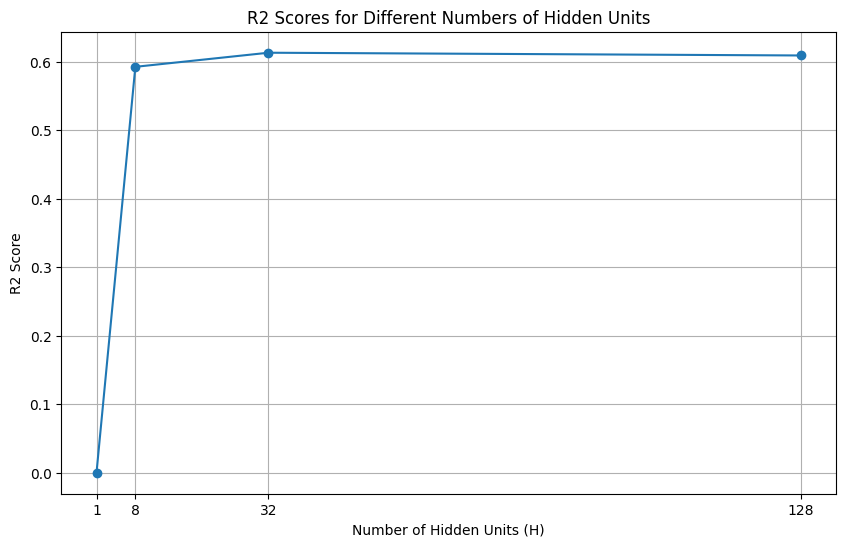

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(hidden_units, feed_forward_result['R2'], marker='o')
plt.title('R2 Scores for Different Numbers of Hidden Units')
plt.xlabel('Number of Hidden Units (H)')
plt.ylabel('R2 Score')
plt.xticks(hidden_units)
plt.grid()
plt.show()

[Q12] Report the model setting, training time, and performance of the neural network model for each value of H. You are also expected to repeat each setting three times for the same hyperparameter setting and report the mean and standard deviation of the training time, R2 and MSE score for each setting.



In [ ]:
feed_forward_result

,H,R2,MSE,Time
0,1,-0.000140,0.071711,6.573776
1,8,0.592278,0.029234,22.692915
2,32,0.612859,0.027758,49.023163
3,128,0.608844,0.028046,99.813910


[Q13] Compare the training time and R2 score of the linear regression model and the best neural network model.



In [ ]:
print('feed forward:')
feed_forward_result[['H', 'R2', 'Time']]

feed forward:


,H,R2,Time
0,1,-0.000140,6.573776
1,8,0.592278,22.692915
2,32,0.612859,49.023163
3,128,0.608844,99.813910


In [ ]:
print('linear regression model:')
enhance_result[['Feature', 'R2', 'Time']]

linear regression model:


,Feature,R2,Time
0,enhanced,0.512287,0.236092


[Q14] Do you notice any trend of R2 and MSE score when you increase the hidden layer size from
1 to 128? Explain the difference between the two metrics in evaluating regression models.

In [ ]:
#haha hehe lala

In this task, you will build a logistic regression model as well as neural network classifiers to predict whether or not the classification target ‘HadHeartAttack’ is ‘true’. You are also required to use the train test split submodule in scikit-learn to split the data, with 80% for training and 20% for validation. As before, we ask that you set random state = 4211 for reproducibility.

Learning of the logistic regression model should use a gradient-descent algorithm by minimizing the cross-entropy loss. It requires that the step size parameter η be specified. Try out a few values (<1) and choose one that leads to stable convergence. You may also decrease η gradually during the learning process to enhance convergence. When set properly, this can be done automatically in scikit-learn. Use the features selected in [Q10] to train the model. During training, record the training time for the logistic regression model. After training, you are required to evaluate your model using accuracy and the F1 score on the validation set. Please be careful to choose the built-in models that are suitable for your tasks, i.e., the default setting of sklearn.linear model.LogisticRegression is not a correct choice for our logistic regression model since it does not use gradient descent.





In [ ]:
from sklearn.linear_model import SGDClassifier, LogisticRegression
from sklearn.metrics import accuracy_score, f1_score

best_feature = first_step_result.nlargest(15, 'R2')['Feature'].tolist()
Logistic_result = pd.DataFrame(columns=['Feature', 'Accuracy', 'F1', 'Time'])


X = combined_df[binary_and_numerical_selected]
Y = numerical_training_data_minmax['HadHeartAttack']
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=4211)
model = SGDClassifier(learning_rate='optimal', eta0=0.01, loss="log_loss", max_iter=100, penalty ='l2')
#model = LogisticRegression()
starting_time = time.time()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
ending_time = time.time()
training_time = ending_time - starting_time
accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
temp_result = pd.DataFrame({'Feature': 'Feature in Q10', 'Accuracy': [accuracy], 'F1': [f1], 'Time': [training_time]})
Logistic_result = pd.concat([Logistic_result, temp_result], ignore_index=True)

<ipython-input-34-aee5c556a3b1>:21: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  Logistic_result = pd.concat([Logistic_result, temp_result], ignore_index=True)


[Q15] Report the model setting, training time, and performance of the logistic regression model. Since the solution found may depend on the initial weight values, you are expected to repeat each setting three times and report the corresponding mean and standard deviation of the training time, accuracy, and the F1 score for each setting.



In [ ]:
Logistic_result

,Feature,Accuracy,F1,Time
0,Feature in Q10,0.946982,0.281089,0.400041


[Q16] Plot the ROC curve calculated on the validation set with the last model in [Q15] and report the AUC value.



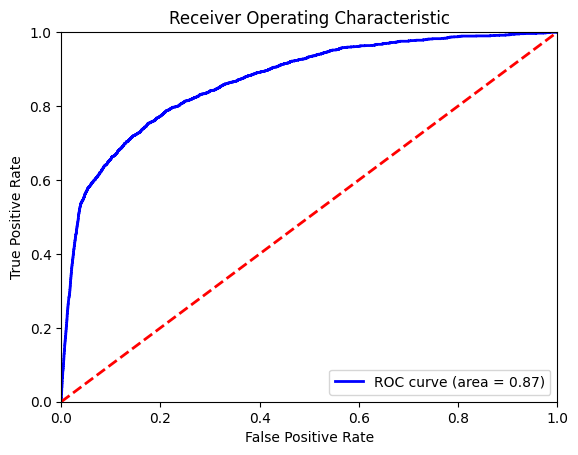

In [ ]:
from sklearn.metrics import roc_curve, auc

y_pred_proba = model.predict_proba(X_test)[:,1]
fpr, tpr, _ = roc_curve(y_test,  y_pred_proba)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='red', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc='lower right')
plt.show()

[Q17] Report the number of true positive, true negative, false positive, and false negative on the validation set with the last model in [Q15]. Discuss why these numbers are helpful in comparison to solely relying on the F1 score, especially on the healthcare dataset.

In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
TN = cm[0][0]
FP = cm[0][1]
FN = cm[1][0]
TP = cm[1][1]
print('True Positive: ', TP, '\nTrue Negative: ' , TN,'\nFalse Positive: ', FP,'\nFalse Negative: ', FN)


True Positive:  408 
True Negative:  36869 
False Positive:  349 
False Negative:  1738


Neural network classifiers generalize logistic regression by introducing one or more hidden layers. Their learning algorithm is similar to that for logistic regression, as described above. Remember to standardize the features before training and validation.

You need to try different numbers of hidden units H ∈ {1, 8, 32, 128} to build different three-hidden-layer neural networks. The hyperparameter early stopping can be set to ‘True’ to avoid overfitting (default is ‘False’). The other hyperparameters may just take their default values. During training, you are expected to record the training time of each model. After training, evaluate your models using accuracy and the F1 score on the validation set. You have to report the accuracy and F1 score for each value of H by plotting them using matplotlib.

In [ ]:
from sklearn.neural_network import MLPClassifier

hidden_units = [1,8,32,128]

feed_forward_result = pd.DataFrame(columns=['H', 'Accuracy', 'F1', 'Time'])

roc_auc_lst = []

for H in hidden_units:
  X = combined_df
  Y = numerical_training_data_minmax['HadHeartAttack']
  X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=4211)
  model = MLPClassifier(hidden_layer_sizes=(H,H,H), early_stopping=True)
  starting_time = time.time()
  model.fit(X_train, y_train)
  y_pred = model.predict(X_test)
  ending_time = time.time()
  training_time = ending_time - starting_time
  accuracy = accuracy_score(y_test, y_pred)
  f1 = f1_score(y_test, y_pred)
  temp_result = pd.DataFrame({'H': [H], 'Accuracy': [accuracy], 'F1': [f1], 'Time': [training_time]})
  feed_forward_result = pd.concat([feed_forward_result, temp_result], ignore_index=True)

  y_pred_proba = model.predict_proba(X_test)[:,1]
  fpr, tpr, _ = roc_curve(y_test,  y_pred_proba)
  tmp = {'H':H, 'fpr':fpr, 'tpr':tpr, 'roc_auc':auc(fpr, tpr)}
  roc_auc_lst.append(tmp)

feed_forward_result

<ipython-input-38-f7b5849e427f>:22: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  feed_forward_result = pd.concat([feed_forward_result, temp_result], ignore_index=True)


,H,Accuracy,F1,Time
0,1,0.945483,0.000000,5.409354
1,8,0.948455,0.320723,19.020923
2,32,0.949091,0.333777,19.777996
3,128,0.948913,0.309646,76.905654


[Q18] Report the model setting, training time, and performance of the neural networks for each value of H. You are also expected to repeat each setting three times and report the mean and standard deviation of the training time, accuracy, and the F1 score for each setting.

In [ ]:
feed_forward_result['Time']

,Time
0,5.409354
1,19.020923
2,19.777996
3,76.905654


[Q19] Plot the accuracy and F1 score for each value of H. Suggest a possible reason for the gap between the accuracy and F1 score.

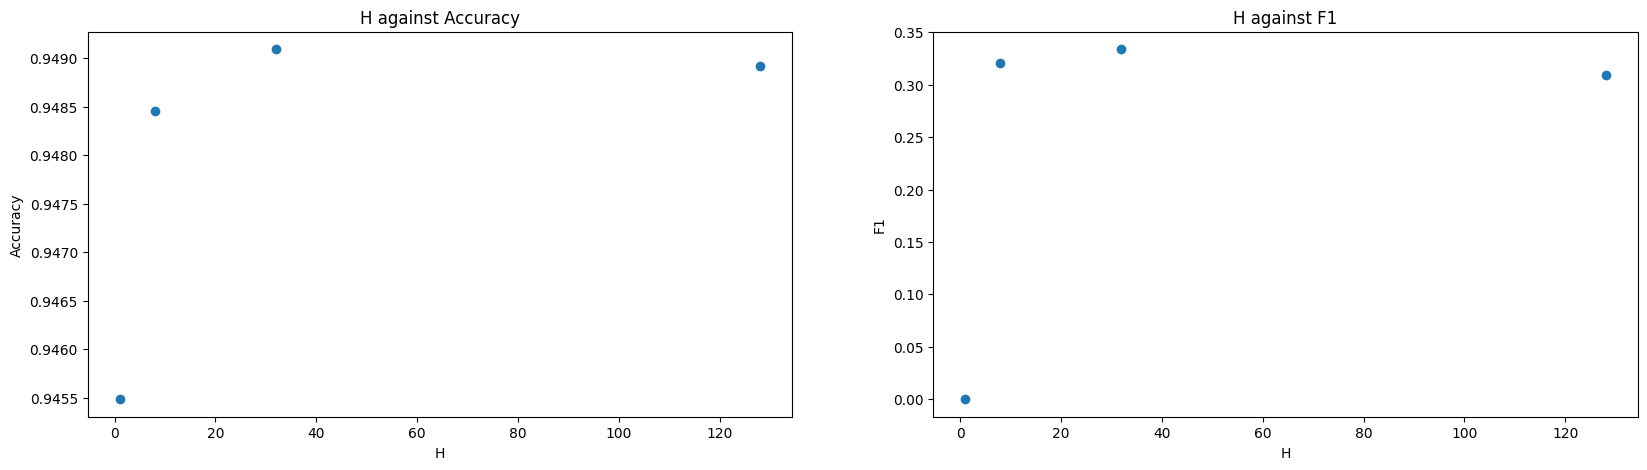

In [ ]:
fig, axs = plt.subplots(1,2)
fig.set_size_inches([20,5])

r2_list = []
for i,ax in enumerate(axs.flat):
    ax.scatter(feed_forward_result['H'], feed_forward_result[feed_forward_result.columns[i+1]])
    ax.set_title(f'H against {feed_forward_result.columns[i+1]}')
    ax.set(ylabel= feed_forward_result.columns[i+1] ,xlabel="H")

plt.show()

[Q20] Compare the training time, accuracy, and the F1 score of the logistic regression model and the best neural network model.

In [ ]:
print('logistic regression model:')
Logistic_result

logistic regression model:


,Feature,Accuracy,F1,Time
0,Feature in Q10,0.946982,0.281089,0.400041


In [ ]:
print('neural network model:')
feed_forward_result

neural network model:


,H,Accuracy,F1,Time
0,1,0.945483,0.000000,5.409354
1,8,0.948455,0.320723,19.020923
2,32,0.949091,0.333777,19.777996
3,128,0.948913,0.309646,76.905654


[Q21] Do you notice any trend when you increase the hidden layer size from 1 to 128? If so, please describe what the trend is and suggest a reason for your observation.

In [ ]:
#haha hehe lala

[Q22] Plot the ROC curve calculated on the validation set with the hidden layer size of 1 and the hidden layer size of 128. Give one reason why we need to examine the ROC curve as well.

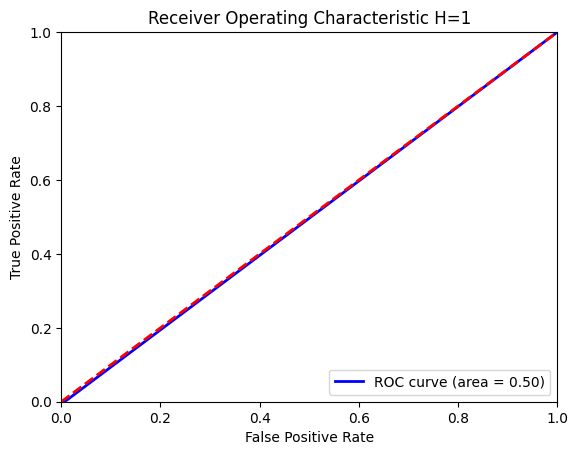

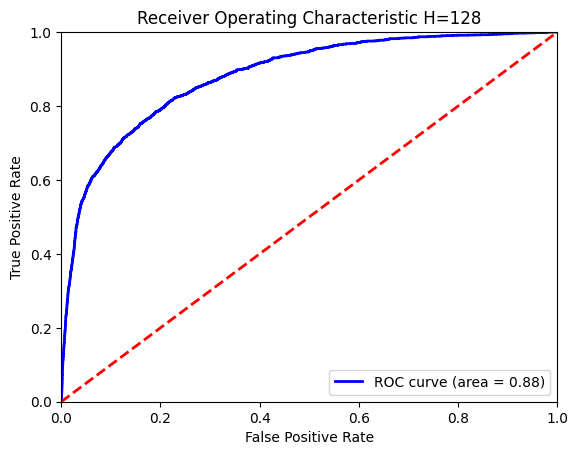

In [ ]:

for tmp in roc_auc_lst[::3]:
  plt.figure()
  plt.plot(tmp['fpr'], tmp['tpr'], color='blue', lw=2, label=f'ROC curve (area = {tmp["roc_auc"]:.2f})')
  plt.plot([0, 1], [0, 1], color='red', lw=2, linestyle='--')
  plt.xlim([0.0, 1.0])
  plt.ylim([0.0, 1.0])
  plt.xlabel('False Positive Rate')
  plt.ylabel('True Positive Rate')
  plt.title('Receiver Operating Characteristic H='+str(tmp['H']))
  plt.legend(loc='lower right')
  plt.show()

In this task, you will build a logistic regression model as well as neural network classifiers to predict whether or not the classification target ‘HadHeartAttack’ is ‘true’. You are also required to use the train test split submodule in scikit-learn to split the data, with 80% for training and 20% for validation. As before, we ask that you set random state = 4211 for reproducibility. This section aims to demonstrate the impact of different preprocessing techniques on model performance by constructing and evaluating multiple pipelines. This task is designed to provide hands-on experience with sklearn’s Pipeline and ColumnTransformer utilities, enabling efficient experimentation with various preprocessing strategies. You could use Pipeline to create a sequence of preprocessing steps for numerical and categorical data separately. Then, ColumnTransformer could be used to apply the respective pipelines to your dataset’s numerical and categorical columns. Your task is to evaluate how different preprocessing combinations affect the performance of three-hidden-layer neural networks to predict whether or not the target ‘HadHeartAttack’is true.

[Q23] Combination A: For numerical features, apply SimpleImputer with mean strategy for imputation. For categorical features, use OneHotEncoder for encoding. Normalize all features with StandardScaler. Do not apply feature selection and feature engineering. Validate this combination with a neural network model.

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

combination_a = pd.DataFrame(columns=['Accuracy', 'F1', 'Time'])

X = training_data.drop('HadHeartAttack', axis=1)
Y = training_data['HadHeartAttack']
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=4211)
numerical_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object']).columns.tolist()
numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])
categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder()),
])
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ])
model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', MLPClassifier(hidden_layer_sizes=(32,32,32), early_stopping=True))
])
starting_time = time.time()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
ending_time = time.time()
training_time = ending_time - starting_time
accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
temp_result = pd.DataFrame({'Accuracy': [accuracy], 'F1': [f1], 'Time': [training_time]})
combination_a = pd.concat([combination_a, temp_result], ignore_index=True)

combination_a

<ipython-input-45-e57c99c1d514>:39: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  combination_a = pd.concat([combination_a, temp_result], ignore_index=True)


,H,Accuracy,F1,Time
0,1,0.945483,0.000000,15.131214
1,8,0.947998,0.312395,16.535726
2,32,0.947820,0.356516,35.662985
3,128,0.948659,0.344470,71.416844


[Q24] Combination B: For numerical features, use StandardScaler for normalization and SimpleImputer with zero strategy for imputation. For categorical features, encode ordinal fea-tures with OrdinalEncoder and remaining with OneHotEncoder. Do not apply feature selection and feature engineering. Validate this combination with a neural network model.

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

combination_b = pd.DataFrame(columns=['Accuracy', 'F1', 'Time'])

X = training_data.drop('HadHeartAttack', axis=1)
Y = training_data['HadHeartAttack']
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=4211)
numerical_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object']).columns.tolist()
ordinal_features = X[['LastCheckupTime', 'RemovedTeeth', 'GeneralHealth', 'ECigaretteUsage']].columns.tolist()
numerical_transformer = Pipeline(steps=[
    ('scaler', StandardScaler()),
    ('imputer', SimpleImputer(strategy='constant', fill_value=0))

])
categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder()),
])
ordinal_transformer = Pipeline(steps=[
    ('ordinal', OrdinalEncoder()),
])
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features),
        ('ord', ordinal_transformer, ordinal_features),
    ])
model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', MLPClassifier(hidden_layer_sizes=(32,32,32), early_stopping=True))
])
starting_time = time.time()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
ending_time = time.time()
training_time = ending_time - starting_time
accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
temp_result = pd.DataFrame({'Accuracy': [accuracy], 'F1': [f1], 'Time': [training_time]})
combination_b = pd.concat([combination_b, temp_result], ignore_index=True)

combination_b

<ipython-input-46-79c516806f20>:45: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  combination_b = pd.concat([combination_b, temp_result], ignore_index=True)


,H,Accuracy,F1,Time
0,1,0.945483,0.000000,12.897037
1,8,0.948684,0.315254,19.126472
2,32,0.949218,0.288865,32.645438
3,128,0.947592,0.201316,72.312808


[Q25] Combination C: Create a custom combination where you choose a different preprocess-ing technique for numerical and categorical features based on your hypothesis of what might work best. This could also involve custom encoders, any appropriate feature selection, or engineering techniques. Validate this combination with a neural network model.

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

combination_c = pd.DataFrame(columns=['Accuracy', 'F1', 'Time'])

X = training_data.drop('HadHeartAttack', axis=1)
Y = training_data['HadHeartAttack']
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=4211)
numerical_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object']).columns.tolist()
ordinal_features = X[['LastCheckupTime', 'RemovedTeeth', 'GeneralHealth', 'ECigaretteUsage']].columns.tolist()
numerical_transformer = Pipeline(steps=[
    ('scaler', RobustScaler()),
    ('imputer', SimpleImputer(strategy='median'))

])
categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder()),
])
ordinal_transformer = Pipeline(steps=[
    ('ordinal', OrdinalEncoder()),
])
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features),
        ('ord', ordinal_transformer, ordinal_features),
    ])
model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', MLPClassifier(hidden_layer_sizes=(32,32,32), early_stopping=True))
])
starting_time = time.time()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
ending_time = time.time()
training_time = ending_time - starting_time
accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
temp_result = pd.DataFrame({'Accuracy': [accuracy], 'F1': [f1], 'Time': [training_time]})
combination_c = pd.concat([combination_c, temp_result], ignore_index=True)

combination_c

<ipython-input-47-fecf24834e34>:45: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  combination_c = pd.concat([combination_c, temp_result], ignore_index=True)


,H,Accuracy,F1,Time
0,1,0.945483,0.000000,12.884423
1,8,0.948328,0.265704,13.895764
2,32,0.948354,0.339721,38.285677
3,128,0.948760,0.354147,72.281775


In this task, you need to use grid search to tune the hyperparameters of a three-hidden-layer feedforward neural network model to predict whether or not the target ‘HadHeartAttack’ is true. All the hyperparameters defined in the MLPClassifier class in scikit-learn except the number of hidden layers can be tuned. Use the best preprocessing techniques in [Q24] and features selected in [Q10] for training and testing.

You are required to use the model selection submodule in scikit-learn to facilitate perform-ing grid search cross-validation for hyperparameter tuning. This is done by randomly sampling 80% of the training instances to train a classifier and then validating it on the remaining 20%. Five such random data splits are performed and the average over these five trials is used to estimate the generalization performance. You are expected to try at least 10 combinations of the hyperparameter setting. Set the random state hyperparameter of the neural network model to 4211 for reproducibility and early stopping to ‘True’ to avoid overfitting.

[Q26] Report five combinations of the hyperparameter settings and highlight the best hyperpa-rameter setting in terms of validation accuracy. You also need to report the mean and standard deviation of the validation accuracy for the five random data splits for each hyperparameter setting. Finally, you need to evaluate the model with the best hyperparameter setting on the testing set and report the testing accuracy.

In [ ]:
from sklearn.model_selection import GridSearchCV

hyperparameter_tuning = pd.DataFrame(columns=['Best Parameter', 'Score', 'Accuracy', 'F1', 'Time'])

X = training_data[selected]
Y = training_data['HadHeartAttack']
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=4211)
numerical_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object']).columns.tolist()
ordinal_features = X[['LastCheckupTime', 'RemovedTeeth', 'ECigaretteUsage']].columns.tolist()
numerical_transformer = Pipeline(steps=[
    ('scaler', RobustScaler()),
    ('imputer', SimpleImputer(strategy='median'))

])
categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder()),
])
ordinal_transformer = Pipeline(steps=[
    ('ordinal', OrdinalEncoder()),
])
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features),
        ('ord', ordinal_transformer, ordinal_features),
    ])
param_grid = {
    'classifier__hidden_layer_sizes': [(32,32), (64,)],
    'classifier__alpha': [0.0001, 0.001],
    'classifier__activation': ['relu', 'tanh', 'logistic'],
}
model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', MLPClassifier(early_stopping=True))
])
grid_search = GridSearchCV(model, param_grid, cv=5, verbose=3)
grid_search.fit(X_train, y_train)

starting_time = time.time()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
ending_time = time.time()
training_time = ending_time - starting_time
best_params = grid_search.best_params_
best_score = grid_search.best_score_
accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
temp_result = pd.DataFrame({'Best Parameter':[best_params], 'Score':[best_score], 'Accuracy': [accuracy], 'F1': [f1], 'Time': [training_time]})
hyperparameter_tuning = pd.concat([hyperparameter_tuning, temp_result], ignore_index=True)

hyperparameter_tuning

Fitting 5 folds for each of 12 candidates, totalling 60 fits
[CV 1/5] END classifier__activation=relu, classifier__alpha=0.0001, classifier__hidden_layer_sizes=(32, 32);, score=0.947 total time=  23.5s
[CV 2/5] END classifier__activation=relu, classifier__alpha=0.0001, classifier__hidden_layer_sizes=(32, 32);, score=0.948 total time=  19.2s
[CV 3/5] END classifier__activation=relu, classifier__alpha=0.0001, classifier__hidden_layer_sizes=(32, 32);, score=0.948 total time=  15.8s
[CV 4/5] END classifier__activation=relu, classifier__alpha=0.0001, classifier__hidden_layer_sizes=(32, 32);, score=0.948 total time=  19.3s
[CV 5/5] END classifier__activation=relu, classifier__alpha=0.0001, classifier__hidden_layer_sizes=(32, 32);, score=0.947 total time=  24.7s
[CV 1/5] END classifier__activation=relu, classifier__alpha=0.0001, classifier__hidden_layer_sizes=(64,);, score=0.948 total time=  17.7s
[CV 2/5] END classifier__activation=relu, classifier__alpha=0.0001, classifier__hidden_layer_siz

<ipython-input-54-50bbf9331895>:50: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  hyperparameter_tuning = pd.concat([hyperparameter_tuning, temp_result], ignore_index=True)


,Best Parameter,Score,Accuracy,F1,Time
0,"{'classifier__activation': 'logistic', 'classi...",0.948016,0.947134,0.207842,27.385327


In [ ]:
Testing = pd.DataFrame(columns=['Accuracy', 'F1', 'Time'])

X_train = training_data[selected]
y_train = training_data['HadHeartAttack']
X_test = testing_data[selected]
y_test = testing_data['HadHeartAttack']
numerical_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object']).columns.tolist()
ordinal_features = X[['LastCheckupTime', 'RemovedTeeth', 'ECigaretteUsage']].columns.tolist()
numerical_transformer = Pipeline(steps=[
    ('scaler', RobustScaler()),
    ('imputer', SimpleImputer(strategy='median'))

])
categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder()),
])
ordinal_transformer = Pipeline(steps=[
    ('ordinal', OrdinalEncoder()),
])
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features),
        ('ord', ordinal_transformer, ordinal_features),
    ])
model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', MLPClassifier(hidden_layer_sizes=(64,), alpha=0.001, activation='logistic', early_stopping=True))
])
model.fit(X_train, y_train)
starting_time = time.time()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
ending_time = time.time()
training_time = ending_time - starting_time
accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
temp_result = pd.DataFrame({'Accuracy': [accuracy], 'F1': [f1], 'Time': [training_time]})
Testing = pd.concat([Testing, temp_result], ignore_index=True)

Testing

<ipython-input-63-ac08cea64a8f>:40: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  Testing = pd.concat([Testing, temp_result], ignore_index=True)


,Accuracy,F1,Time
0,0.948969,0.301141,49.379184
